# PART A – Classification Problem
# Network Intrusion Detection Using Machine Learning
## Problem Statement
Modern networks generate large amounts of traffic data. Organizations use Intrusion Detection Systems (IDS) to identify malicious activities and cyberattacks. 
Develop a machine learning model that classifies network traffic as:
- Normal
- Attack
or multiple attack categories depending on the dataset used.

## Data Exploration

Install the required packages (if needed)
```bash
pip install -r requirements.txt
```

In [1]:
# Loading Libraries for Exploratory Data Analysis
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Path to dataset
database_path = '~/My Drive/ObsidianVaults/NYP/EG272S-Intelligent Services/EG272S_Assignment1/data/DrDoS_DNS.csv'

# Load dataset
data = pd.read_csv(database_path)

# View data
data.head()

,protocol,flow_duration,total_forward_packets,total_backward_packets,total_forward_packets_length,total_backward_packets_length,forward_packet_length_mean,backward_packet_length_mean,forward_packets_per_second,backward_packets_per_second,forward_iat_mean,backward_iat_mean,flow_iat_mean,flow_packets_per_seconds,flow_bytes_per_seconds,label
0,17,2468,4,0,1580.0,0.0,395.0,0.0,1620.745543,0.0,822.666667,0.0,822.666667,1620.745543,6.401945e+05,DrDoS_DNS
1,17,133,4,0,5888.0,0.0,1472.0,0.0,30075.187970,0.0,44.333333,0.0,44.333333,30075.187970,4.427068e+07,DrDoS_DNS
2,17,33509,200,0,88000.0,0.0,440.0,0.0,5968.545764,0.0,168.386935,0.0,168.386935,5968.545764,2.626160e+06,DrDoS_DNS
3,17,288495,200,0,88000.0,0.0,440.0,0.0,693.252916,0.0,1449.723618,0.0,1449.723618,693.252916,3.050313e+05,DrDoS_DNS
4,17,9,2,0,2062.0,0.0,1031.0,0.0,222222.222222,0.0,9.000000,0.0,9.000000,222222.222222,2.291111e+08,DrDoS_DNS


In [3]:
# Reviewing data columns against the data dictionary
# to develop a preliminary understanding of the data and
# note the columns with missing va;ues.
data.info()

# Count of missing values for variables with missing values
for col in data.columns:
  if data[col].isnull().sum() > 0:
    print(f'{col} has {data[col].isnull().sum()} missing values')

<class 'pandas.DataFrame'>
RangeIndex: 33925 entries, 0 to 33924
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   protocol                       33925 non-null  int64  
 1   flow_duration                  33925 non-null  int64  
 2   total_forward_packets          33925 non-null  int64  
 3   total_backward_packets         33925 non-null  int64  
 4   total_forward_packets_length   33925 non-null  float64
 5   total_backward_packets_length  33925 non-null  float64
 6   forward_packet_length_mean     33925 non-null  float64
 7   backward_packet_length_mean    33925 non-null  float64
 8   forward_packets_per_second     33925 non-null  float64
 9   backward_packets_per_second    33925 non-null  float64
 10  forward_iat_mean               33925 non-null  float64
 11  backward_iat_mean              33925 non-null  float64
 12  flow_iat_mean                  33925 non-null  float64
 1

### Target Variable is 'label'

label
DrDoS_DNS    0.96675
BENIGN       0.03325
Name: proportion, dtype: float64
label
DrDoS_DNS    32797
BENIGN        1128
Name: count, dtype: int64


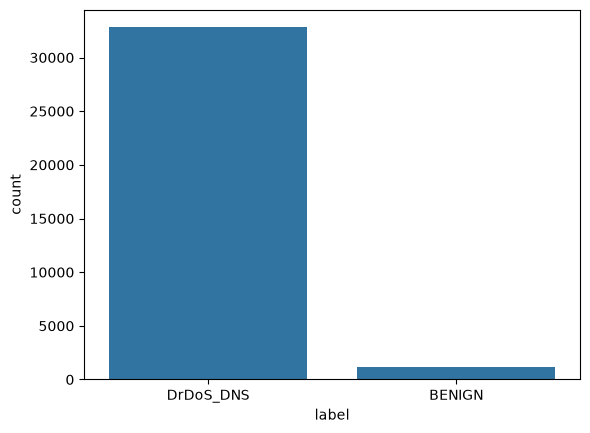

In [4]:
# Count values for label variable and its proportion
print(data['label'].value_counts(normalize=True))
print(data['label'].value_counts())

# Plot countplot for loan_status
sns.countplot(x='label', data=data)
plt.show()

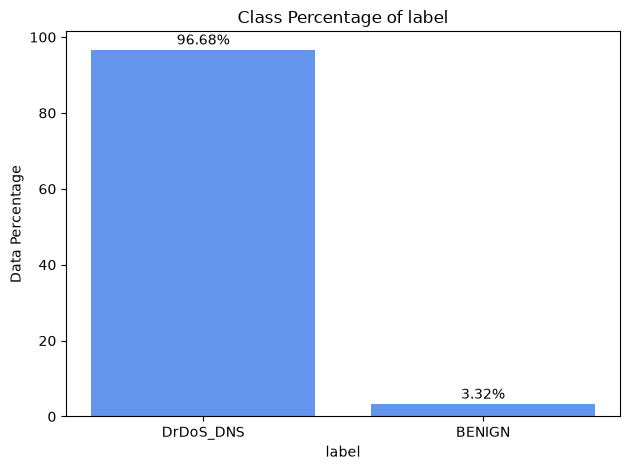

In [5]:
# Calculating class percentages

class_percentage = round(data.label.value_counts(normalize = True) * 100, 2)

#plt.figure(figsize = (8, 5))
bars = plt.bar(class_percentage.index, class_percentage, color = 'cornflowerblue')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha = 'center', va = 'bottom', color = 'black')

plt.xlabel('label')
plt.ylabel('Data Percentage')
plt.title('Class Percentage of label')

plt.xticks(class_percentage.index)

plt.tight_layout()
plt.show()

### Insights from the Distribution:

**Imbalance in Classes**: There is a significant class imbalance with a majority of the label being **DrDos_DNS**. This imbalance can impact the performance of machine learning models, potentially leading them to be biased towards predicting the majority class ("**DrDos_DNS**").

**Impact on Model Training**: Due to the skewed distribution, models might need techniques like resampling, use of balanced class weights, or specialized algorithms for imbalanced data to better predict the minority class ("**BENIGN**").

In [6]:
# Get list of numerical variables
num_cols = []
for col in data.columns:
    if data[col].dtype != 'str':
        num_cols.append(col)

print(f'There are {len(num_cols)} numerical variables:')
print(num_cols) 

There are 15 numerical variables:
['protocol', 'flow_duration', 'total_forward_packets', 'total_backward_packets', 'total_forward_packets_length', 'total_backward_packets_length', 'forward_packet_length_mean', 'backward_packet_length_mean', 'forward_packets_per_second', 'backward_packets_per_second', 'forward_iat_mean', 'backward_iat_mean', 'flow_iat_mean', 'flow_packets_per_seconds', 'flow_bytes_per_seconds']


In [7]:
# Descriptive Statistics for all numerical variables
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
protocol,33925.0,1.700000e+01,0.000000e+00,17.000000,1.700000e+01,1.700000e+01,1.700000e+01,1.700000e+01
flow_duration,33925.0,8.597836e+04,1.831408e+06,1.000000,4.400000e+01,2.350000e+02,2.911900e+04,1.183569e+08
total_forward_packets,33925.0,6.551328e+01,8.938778e+01,2.000000,2.000000e+00,2.000000e+00,1.780000e+02,4.000000e+02
total_backward_packets,33925.0,6.596905e-02,3.581863e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
total_forward_packets_length,33925.0,2.940005e+04,3.887001e+04,0.000000,9.600000e+02,2.672000e+03,7.788800e+04,1.760000e+05
total_backward_packets_length,33925.0,6.161120e+00,3.792449e+01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.560000e+02
forward_packet_length_mean,33925.0,6.422248e+02,4.348924e+02,0.000000,4.361600e+02,4.400000e+02,9.320000e+02,1.472000e+03
backward_packet_length_mean,33925.0,3.072071e+00,1.889888e+01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.780000e+02
forward_packets_per_second,33925.0,1.792975e+05,4.423623e+05,0.039297,5.604045e+03,9.478673e+03,4.545455e+04,4.000000e+06
backward_packets_per_second,33925.0,2.745483e+00,1.552335e+01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,9.815469e+01


In [8]:
# Drop 'protocol' variable
data = data.drop(['protocol'], axis =1)

# Update list of numerical variables
num_cols = [x for x in num_cols if x != 'protocol']

print(f'There are {len(num_cols)} numerical variables:')
print(num_cols) 

There are 14 numerical variables:
['flow_duration', 'total_forward_packets', 'total_backward_packets', 'total_forward_packets_length', 'total_backward_packets_length', 'forward_packet_length_mean', 'backward_packet_length_mean', 'forward_packets_per_second', 'backward_packets_per_second', 'forward_iat_mean', 'backward_iat_mean', 'flow_iat_mean', 'flow_packets_per_seconds', 'flow_bytes_per_seconds']


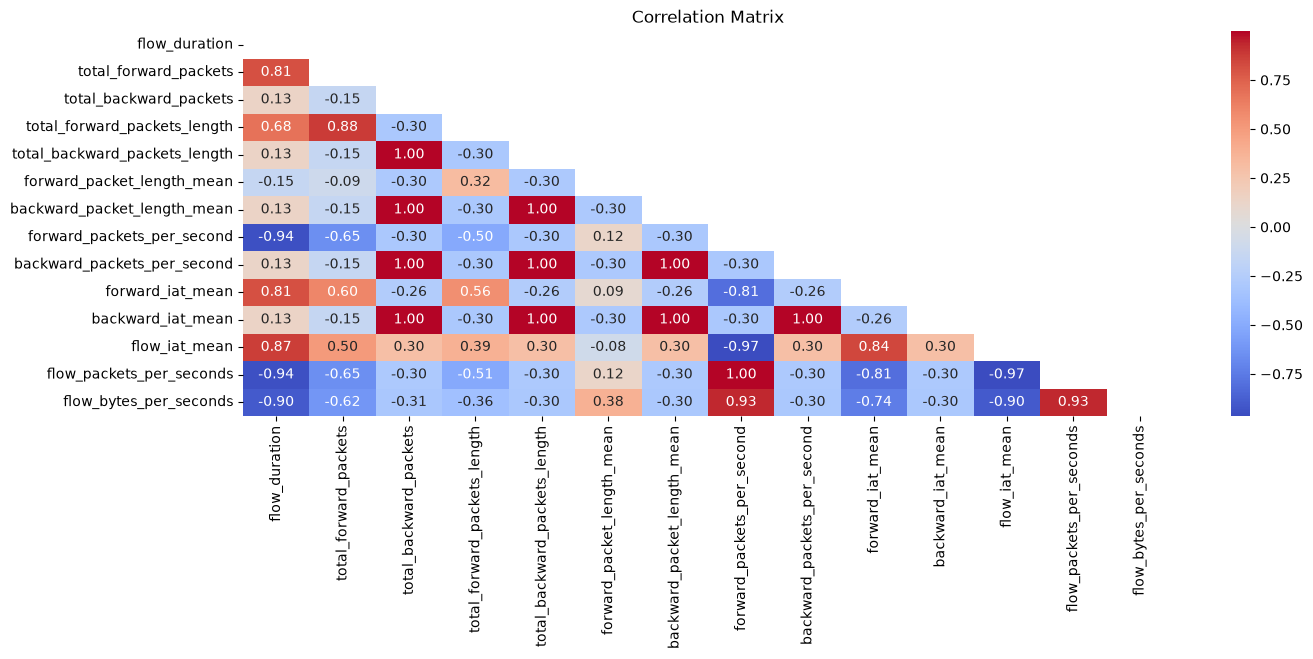

In [9]:
# Plotting Correlation Analysis Heatmaps
# Correlation matrix
data_num = data[num_cols]

plt.figure(figsize=(15, 5))
corr_matrix = data_num.corr(method='spearman')  # Exclude target from correlation matrix calculation

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.title('Correlation Matrix')
plt.show()

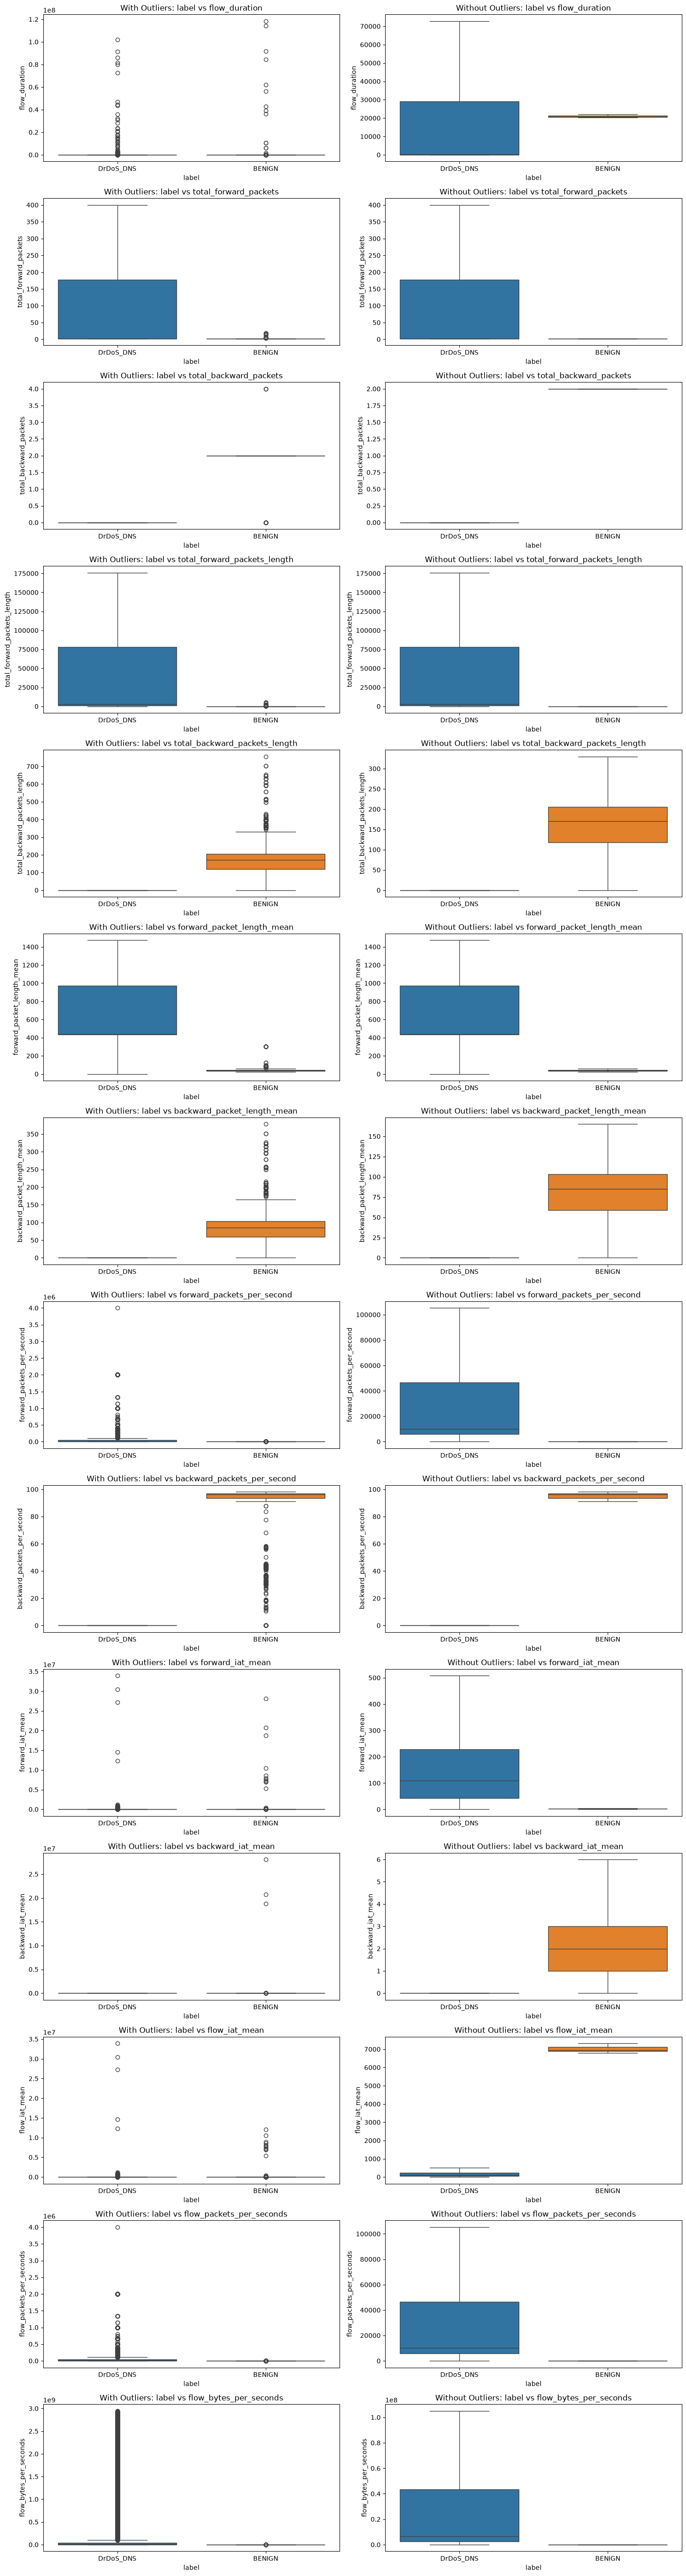

In [10]:
# Define Plot Box Plots for Numerical Variables against Target Variable
def plot_box_plots(df, num_cols, category ='label'):
  num_features = len(num_cols)
  num_rows = num_features  # Calculate the number of rows needed
  fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(15, num_rows * 4))  # Adjust figure size accordingly
  axes = axes.flatten()

  i = 0  # Initialize index for axes
  for col in df.columns:
      if df[col].dtype == 'str' and col == category:
          for num in num_cols:

              # Plot with outliers
              sns.boxplot(x=col, y=num, data=df, ax=axes[i], hue=col)
              axes[i].set_title(f'With Outliers: {col} vs {num}')
              i += 1

              # Plot without Outliers
              sns.boxplot(x=col, y=num, data=df, ax=axes[i], hue=col, showfliers=False)
              axes[i].set_title(f'Without Outliers: {col} vs {num}')
              i += 1

  # Adjust layout and display
  plt.tight_layout()
  plt.show()

plot_box_plots(data, num_cols, category ='label')

### Features Selection and Reasoning for the Selection
Upon analysing the Correlation Matrix and the box plots for each of the features fields as well as the raw csv data, 
1) The field **protocol** is to be removed as it is only contains a contant of "17"
2) The field "forward_packet_length_mean" is an average of the field "total_forward_packets_length" over the field "total_forward_packets". The field "forward_packet_length_mean" contained the information of "total_forward_packets_length", hence "**total_forward_packets_length**" is excluded.
3) The field "backward_packet_length_mean" is an average of the field "total_backward_packets_length" over the field "total_backward_packets". The field "backward_packet_length_mean" contained the information of "total_backward_packets_length", hence "**total_backward_packets_length**" is excluded.

In [11]:
# Drop 'total_forward_packets_length' and 'total_backward_packets_length' fields
data = data.drop(['total_forward_packets_length', 'total_backward_packets_length'], axis =1)


### Split the data into Train and Test Sets

In [12]:
# Convert 'label' to boolean where 'BENIGN' is 0 and 'DrDoS_DNS' is 1
data['target'] = data['label'].map({'BENIGN':0, 'DrDoS_DNS':1})

In [13]:
from sklearn.model_selection import train_test_split

# Separate X and Y sets
X = data.drop(['label', 'target'], axis=1)
y = data['target']

# Split the data into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Over-Sampling the minority class "BENIGN" from dataset

In [14]:
# Duplicate a copy of X_train and X_test
X_train_Org = X_train.copy()
X_test_Org = X_test.copy()

# Oversample minority class "BENIGN" from dataset
from imblearn.over_sampling import RandomOverSampler

rus = RandomOverSampler(sampling_strategy = 'auto')
X_train, y_train = rus.fit_resample(X_train, y_train)

In [15]:
from collections import Counter

# Print shape of Train and Test Set
print('Training Set:')
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

print('Test Set:')
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Total data from resampling
total_row_Org = X_train_Org.shape[0] + X_test_Org.shape[0]
total_row = X_train.shape[0] + X_test.shape[0]
print(f"Total data from resampling: {total_row}, increased from original {total_row_Org}")


# Proportion of Train and Test Split (after resampling)
print(f"Proportion of Train Split (after resampling): {X_train.shape[0]/total_row:.2f}")
print(f"Proportion of Test Split  (after resampling): {X_test.shape[0]/total_row:.2f}\n")

# Total data from Original (before resampling)
print(f"Total original data before resampling: {len(data)}")
print(f"Total number of rows in X_train added (Minority class): {total_row - len(data)} or {(total_row - len(data))/len(data):.2f}")

# Proportion of Train and Test Split
print(f"Proportion of Train Split (based on original data): {len(X_train_Org)/len(data):.2f}")
print(f"Proportion of Test Split  (based on original data): {len(X_test_Org)/len(data):.2f}")

print('\n======================================================\n')

# Proportion of y_train
counts = Counter(y_train)
print(f"Proportion of Majority class ['DrDoS_DNS'] (train set): {counts[1]/len(y_train):.2f}")
print(f"Proportion of Minority class ['BENIGN'] (train set): {counts[0]/len(y_train):.2f}")
unique_values, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique_values, counts)))

print('\n======================================================\n')

# Count value for y_test
counts = Counter(y_test)
print(f"Proportion of Majority class ['DrDoS_DNS'] (test set): {counts[1]/len(y_test):.2f}")
print(f"Proportion of Minority class ['BENIGN'] (test set): {counts[0]/len(y_test):.2f}")
unique_values, counts = np.unique(y_test, return_counts=True)
print(dict(zip(unique_values, counts)))

Training Set:
X_train shape: (52476, 12)
y_train shape: (52476,)

Test Set:
X_test shape: (6785, 12)
y_test shape: (6785,)

Total data from resampling: 59261, increased from original 33925
Proportion of Train Split (after resampling): 0.89
Proportion of Test Split  (after resampling): 0.11

Total original data before resampling: 33925
Total number of rows in X_train added (Minority class): 25336 or 0.75
Proportion of Train Split (based on original data): 0.80
Proportion of Test Split  (based on original data): 0.20


Proportion of Majority class ['DrDoS_DNS'] (train set): 0.50
Proportion of Minority class ['BENIGN'] (train set): 0.50
{np.int64(0): np.int64(26238), np.int64(1): np.int64(26238)}


Proportion of Majority class ['DrDoS_DNS'] (test set): 0.97
Proportion of Minority class ['BENIGN'] (test set): 0.03
{np.int64(0): np.int64(226), np.int64(1): np.int64(6559)}


### Model Training

In [ ]:
# Load Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer

from sklearn.metrics import (
    roc_auc_score,
    auc,
    roc_curve,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix
    )

import time
import warnings
import logging
warnings.filterwarnings('ignore')


In [17]:
# Determine the list of numerical features
num_var = X_train.select_dtypes(include=['float64', 'int64']).columns

# Define the model and respective hyperparameters search space and train the models
model_class = {
    'sgd': SGDClassifier,
    'clf': DecisionTreeClassifier,
    'random_forest': RandomForestClassifier  # Note: no parentheses
    }

model_params = {
    'sgd': {
        'model__loss': ['log_loss'], # ‘log_loss’ gives logistic regression, a probabilistic classifier.
        'model__penalty': ['l1', 'l2'], # default is l2
        'model__n_jobs': [-1], # 1 means using all processors
    },
    'clf': {
        'model__max_depth': [None, 10, 20, 30],
    },
    'random_forest': {
        'model__max_depth': [None, 10, 20, 30],
        'model__n_jobs': [-1],
    },
}

### Helper Functions for Model Evaluations

In [18]:
# Define Function to Plot ROC and PRC Curve for each model and return the ROC-AUC, PRC-AUC scores and the figure
def plot_curves(model_name, model_data, X, y):

    # Set Plot Size
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Probabilities for positive class
    probas = model_data.predict_proba(X)
    preds = probas[:, 1] # Extract probabilities for positive class

    # ROC Curve and ROC-AUC
    fpr, tpr, _ = roc_curve(y, preds)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

    # Precision-Recall Curve and PRC-AUC
    precision, recall, _ = precision_recall_curve(y, preds)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, lw=2, label=f'{model_name} (AUC = {pr_auc:.2f})')

    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Receiver Operating Characteristic')
    ax1.legend(loc="lower right")

    ax2.plot([0, 1], [1, 0], color='navy', lw=2, linestyle='--')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlim([0.0, 1.0])
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc="lower left")

    plt.tight_layout()
    
    # Save plot as a separate PNG file
    fig_path = f"{model_name}_roc_prc_curves.png"
    fig.savefig(fig_path)
    plt.close(fig)

    return fig_path

    
# Define Function to compute evaluation metrices for each model
def compute_metrices(model_data, X, y):

    # Make predictions on the X
    probas = model_data.predict_proba(X)
    preds = probas[:, 1] # Extract probabilities for positive class

    # Calculate precision-recall curve
    prc = precision_recall_curve(y, preds)
    precisions, recalls, thresholds = prc
    pr_auc = auc(recalls, precisions)

    # ROC Curve and ROC-AUC
    fpr, tpr, _ = roc_curve(y, preds)
    roc_auc = auc(fpr, tpr)
    
    prc_df = pd.DataFrame(prc)
    prc_df = prc_df.T
    prc_df.columns = ['precision', 'recall', 'threshold']

    # Calculate F1 scores and find index of highest F1 score
    prc_df['Precision_Recall'] = prc_df['precision'] - prc_df['recall']
    prc_df['F1_Score'] = 2 * (prc_df['precision'] * prc_df['recall']) / (prc_df['precision'] + prc_df['recall'])
    prc_df['F1_Score'] = prc_df['F1_Score'].fillna(0)

    # Threshold with highest F1 Score
    idx = prc_df.loc[prc_df['F1_Score'].idxmax()]
    threshold = float(idx['threshold'])
    f1 = float(idx['F1_Score'])
    precision = float(idx['precision'])
    recall = float(idx['recall'])

    # Results Dictionary
    results = {
        'ROC-AUC': float(roc_auc),
        'PRC-AUC': float(pr_auc),
        'F1_score': f1,
        'Precision': precision,
        'Recall': recall,
        'Threshold': threshold
    }

    return results


def cm_plot(model_data, X, y, threshold, title = None):
    # Make predictions on the X
    probas = model_data.predict_proba(X)
    preds = probas[:, 1] # Extract probabilities for positive class

    # Predictions for thresholds and confusion matrix
    predictions = (preds >= threshold).astype(int)
    cm = confusion_matrix(y, predictions)
    
    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm", ax=ax)
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.set_title(f'Confusion Matrix, based on {title} Threshold: {threshold:.2f}')
    
    # Save plot as a separate PNG file
    fig_path = f"{model_name}_confusion_matrix_{title}_threshold.png"
    fig.savefig(fig_path)
    plt.close(fig)

    return fig_path

### Training the Models

In [19]:
# Setup cross validation folds
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Concat X_test with y_test
eval_data = pd.concat([X_test, y_test], axis=1)

In [20]:
# Create an empty list to store the results
results = []
cvfit_results = []
start_time = time.time()

# Train the models
for model_name, params in model_params.items():
        # Build pipeline from scratch every time they are called.
        # Data preprocessing step with ColumnTransformer
        num_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
            ])
        # Preprocessing for categorical data
        # cat_transformer = Pipeline(steps=[
        #     ('imputer', SimpleImputer(strategy='most_frequent')),
        #     ('onehot', OneHotEncoder(handle_unknown='ignore'))
        #     ])

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', num_transformer, num_var),
                # ('cat', cat_transformer, cat_var),
            ],
            remainder='passthrough', # Use 'passthrough' for columns not specified
            )

        # Build pipeline for the model
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model_class[model_name]()) # ensure the model is instantiated with ()
        ])

        grid_search = GridSearchCV(pipeline,
                                    param_grid = params,
                                    cv=cv,
                                    scoring='roc_auc',
                                    verbose=1,
                                    return_train_score=True,
                                    n_jobs=-1) # Set n_jobs to -1 to use all available cores

        print(f"\nTraining {model_name}...")
        grid_search.fit(X_train, y_train)
        
        # Store the cross-validation results
        cv_results = grid_search.cv_results_
        for i in range(len(cv_results['mean_train_score'])):
            cvfit_results.append({
                'model': model_name,
                'fit_index': i,
                'params': grid_search.best_params_,
                'mean_train_score': cv_results['mean_train_score'][i],
                'mean_validation_score': cv_results['mean_test_score'][i],
            })

        # Store the best model for later use
        results.append({
            'model': model_name,
            'best_params': grid_search.best_params_,
            'best_train_score': grid_search.cv_results_['mean_train_score'][grid_search.best_index_],
            'best_validation_score': grid_search.best_score_,
            'model_data': grid_search.best_estimator_,
        })

        # Compute Evaluation Metrices
        test_metrics = compute_metrices(grid_search.best_estimator_, X_test, y_test)
        print(f"Model: {model_name}, Test Metrics: {test_metrics}")

end_time = time.time()
print(f"Total time (training + evaluation): {end_time - start_time:.2f} seconds")


Training sgd...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Model: sgd, Test Metrics: {'ROC-AUC': 1.0, 'PRC-AUC': 1.0, 'F1_score': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'Threshold': 0.039644881338981246}

Training clf...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Model: clf, Test Metrics: {'ROC-AUC': 1.0, 'PRC-AUC': 1.0, 'F1_score': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'Threshold': 1.0}

Training random_forest...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Model: random_forest, Test Metrics: {'ROC-AUC': 1.0, 'PRC-AUC': 1.0, 'F1_score': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'Threshold': 0.95}
Total time (training + evaluation): 5.84 seconds


### Model Evaluations

In [22]:
# Convert cv_results to DataFrame
cvfit_results_df = pd.DataFrame(cvfit_results)
cvfit_results_df = cvfit_results_df.sort_values(by='mean_validation_score', ascending=False)

# Convert results to DataFrame
all_results_df = pd.DataFrame(results)
all_results_df = all_results_df.sort_values(by='best_validation_score', ascending=False)

all_results_df[['model', 'best_train_score', 'best_validation_score']]

,model,best_train_score,best_validation_score
2,random_forest,1.000000,1.000000
1,clf,1.000000,0.999942
0,sgd,0.999832,0.999782


### Plot ROC and PRC Curve

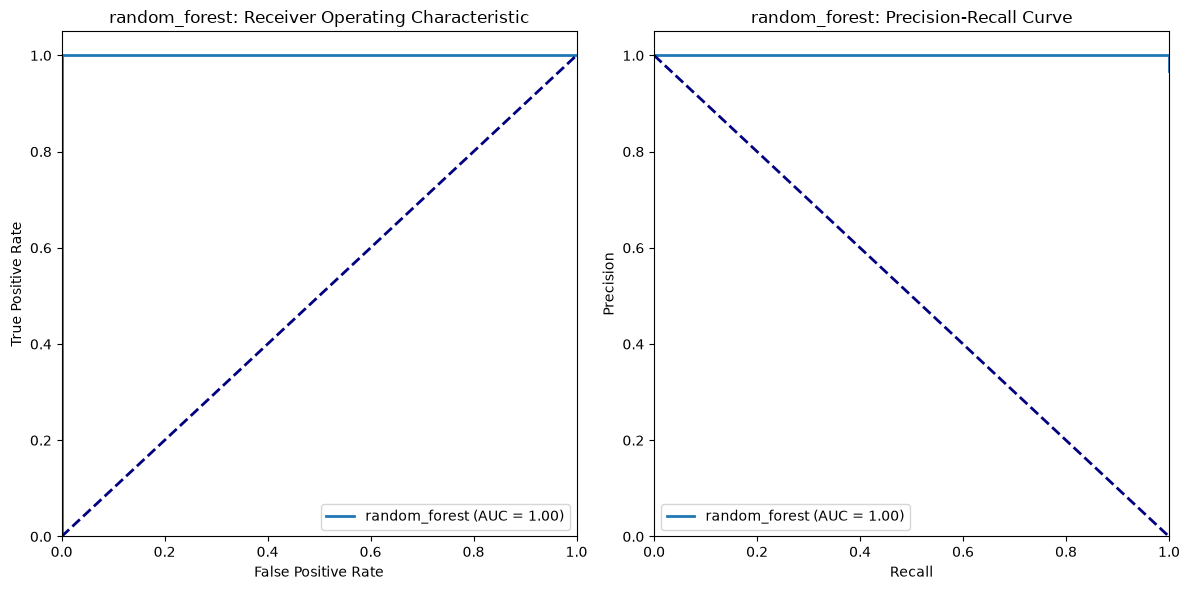

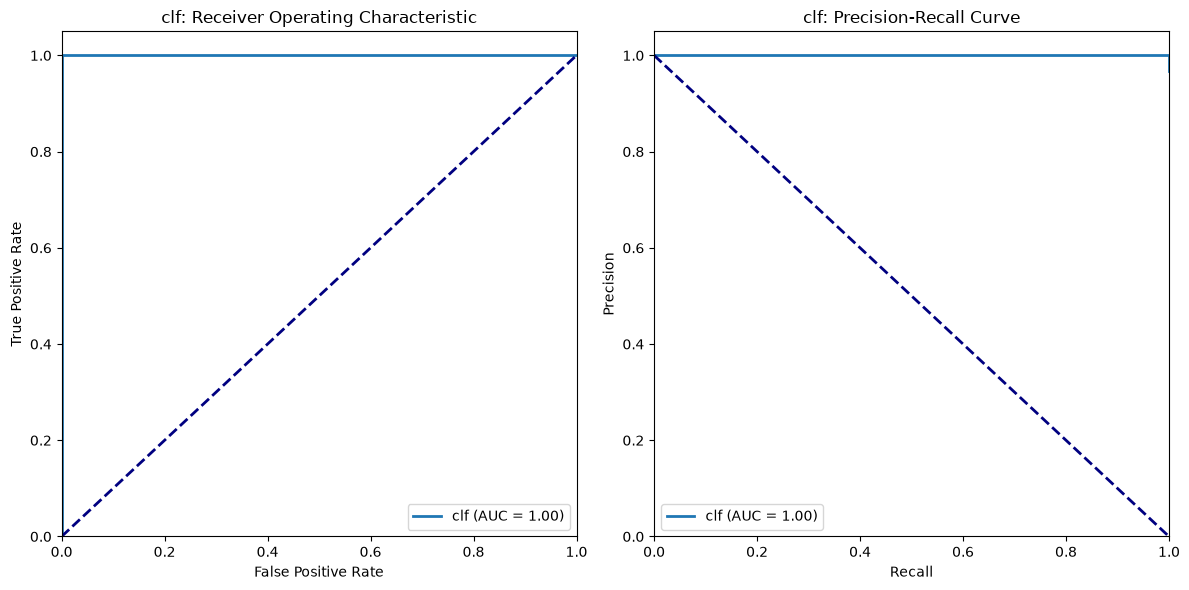

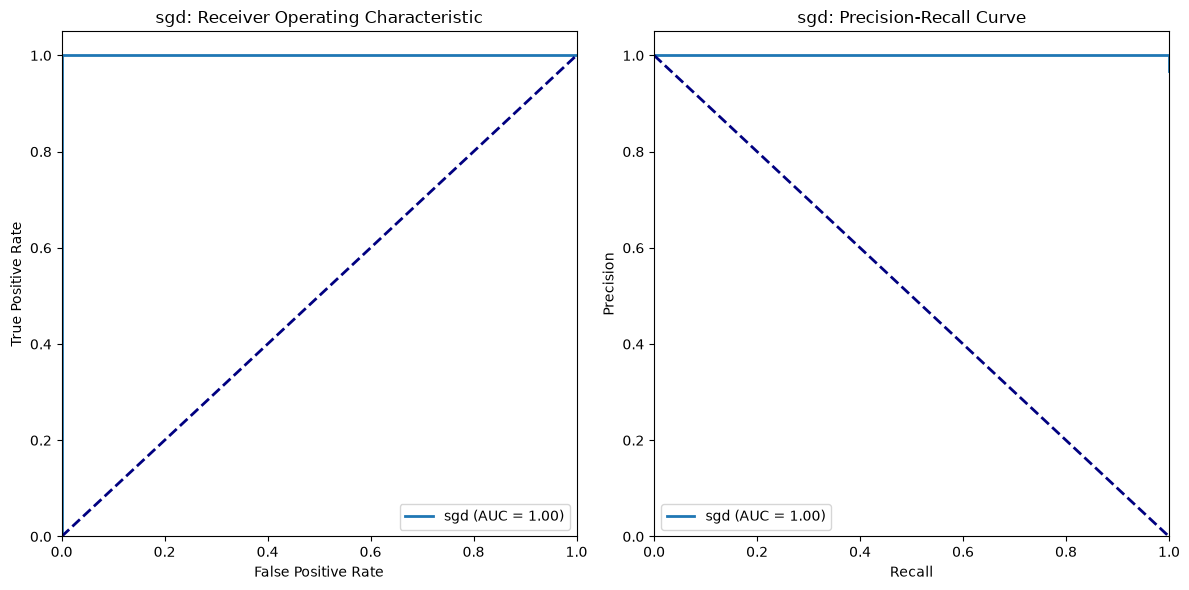

In [25]:
# Define Function to Plot ROC and PRC Curve for each model separately
def plot_roc_prc_curves(results_df, X_test, y_test):

    # Create a separate ROC/PRC figure pair for each model
    for index in results_df.index:
        model_name = results_df.loc[index, 'model']
        model_data = results_df.loc[index, 'model_data']

        # Probabilities for positive class
        y_scores = model_data.predict_proba(X_test)[:, 1]

        # ROC Curve and ROC-AUC
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        roc_auc = auc(fpr, tpr)

        # Precision-Recall Curve and PRC-AUC
        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        pr_auc = auc(recall, precision)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

        ax1.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')
        ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax1.set_xlim([0.0, 1.0])
        ax1.set_ylim([0.0, 1.05])
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.set_title(f'{model_name}: Receiver Operating Characteristic')
        ax1.legend(loc="lower right")

        ax2.plot(recall, precision, lw=2, label=f'{model_name} (AUC = {pr_auc:.2f})')
        ax2.plot([0, 1], [1, 0], color='navy', lw=2, linestyle='--')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlim([0.0, 1.0])
        ax2.set_title(f'{model_name}: Precision-Recall Curve')
        ax2.legend(loc="lower left")

        plt.tight_layout()
        plt.show()

# Plot ROC and PRC Curve
plot_roc_prc_curves(all_results_df, X_test, y_test)

In [29]:
# Define Function to Generate Model Evaluation Results
def model_evaluation(X_train, y_train, X_test, y_test, results_df):
  # Iterate over the models and calculate the ROC AUC score for the train and test sets
  for index, row in results_df.iterrows():
      model_name = row['model']
      model_data = row['model_data']
      best_params = row['best_params']

      print(f"\nModel {index}: {model_name}")
      print(f"Best Parameters: {best_params}\n")

      # Make predictions on the train and test set
      probas_train = model_data.predict_proba(X_train)
      preds_train = probas_train[:, 1] # Extract probabilities for positive class

      probas_test = model_data.predict_proba(X_test)
      preds_test = probas_test[:, 1] # Extract probabilities for positive class

      y_pred = model_data.predict(X_test)

      # Calculate evaluation metrics
      roc_auc_train = roc_auc_score(y_train, preds_train)
      roc_auc_test = roc_auc_score(y_test, preds_test)

      # Update the results dataframe
      results_df.loc[index, 'roc_auc_train'] = roc_auc_train
      results_df.loc[index, 'roc_auc_test'] = roc_auc_test

      # Calculate precision-recall curve on test set
      prc = precision_recall_curve(y_test, preds_test)
      precisions, recalls, thresholds = prc
      prc_auc_test = auc(recalls, precisions)
      results_df.loc[index, 'prc_auc_test'] = prc_auc_test

      prc_df = pd.DataFrame(prc)
      prc_df = prc_df.T
      prc_df.columns = ['precision', 'recall', 'threshold']

      # Calculate F1 scores and find index of highest F1 score
      prc_df['Precision_Recall'] = prc_df['precision'] - prc_df['recall']
      prc_df['F1_Score'] = 2 * (prc_df['precision'] * prc_df['recall']) / (prc_df['precision'] + prc_df['recall'])
      prc_df['F1_Score'] = prc_df['F1_Score'].fillna(0)

      # Threshold with highest F1 Score
      idx = prc_df.loc[prc_df['F1_Score'].idxmax()]
      threshold = idx['threshold']
      highf1 = idx['F1_Score']
      precision = idx['precision']
      recall = idx['recall']

      # Calculate F1 score for best threshold
      y_pred = (preds_test >= threshold).astype(int)
      optimal_f1 = f1_score(y_test, y_pred)

      results_df.loc[index, 'F1 score'] = optimal_f1
      results_df.loc[index, 'Precision'] = precision
      results_df.loc[index, 'Recall'] = recall
      results_df.loc[index, 'Threshold'] = threshold

  results_df_sorted = results_df.sort_values(by='roc_auc_test', ascending=False)
  results_df_sorted = results_df_sorted.reset_index(drop=True)

  print(f'\n--------- ROC-AUC Scores ---------\n')
  print(results_df_sorted[['model', 'roc_auc_train', 'roc_auc_test', 'prc_auc_test']])

  print(f'\n--------- F1 Scores & Threshold  ---------\n')
  print(results_df_sorted[['model','F1 score', 'Precision', 'Recall', 'Threshold']])

  return results_df_sorted


# Generate Model Evaluation Results
results_df_sorted = model_evaluation(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, results_df=all_results_df)


Model 2: random_forest
Best Parameters: {'model__max_depth': None, 'model__n_jobs': -1}


Model 1: clf
Best Parameters: {'model__max_depth': None}


Model 0: sgd
Best Parameters: {'model__loss': 'log_loss', 'model__n_jobs': -1, 'model__penalty': 'l1'}


--------- ROC-AUC Scores ---------

           model  roc_auc_train  roc_auc_test  prc_auc_test
0  random_forest       1.000000           1.0           1.0
1            clf       1.000000           1.0           1.0
2            sgd       0.999756           1.0           1.0

--------- F1 Scores & Threshold  ---------

           model  F1 score  Precision  Recall  Threshold
0  random_forest       1.0        1.0     1.0   0.950000
1            clf       1.0        1.0     1.0   1.000000
2            sgd       1.0        1.0     1.0   0.039645


In [31]:
print('\n--------- Best Model (After Evaluation with Test Data) ---------\n')

selected_model = 'random_forest'

# index of the selected model
index = results_df_sorted[results_df_sorted['model'] == selected_model].index[0]

# Print the best model
print (f"Best Model: {results_df_sorted.loc[index]['model']}")
print (f"Best Parameters: {results_df_sorted.iloc[index]['best_params']}")

print('\n------------------------------------\n')

# Save the best model
best_model_data = results_df_sorted.iloc[index]['model_data']


--------- Best Model (After Evaluation with Test Data) ---------

Best Model: random_forest
Best Parameters: {'model__max_depth': None, 'model__n_jobs': -1}

------------------------------------



### Classification Report and Confusion Matrix


========== random_forest: Based on Highest Probability ==========

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       1.00      1.00      1.00      6559

    accuracy                           1.00      6785
   macro avg       1.00      1.00      1.00      6785
weighted avg       1.00      1.00      1.00      6785



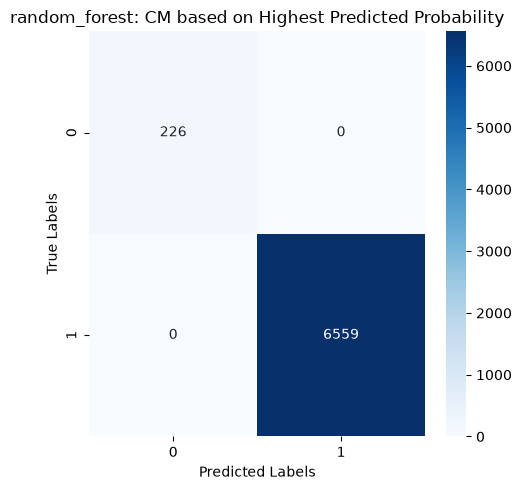

In [32]:
# Define Function to Generate Classification Report with the Thresholds
def print_cm_threshold(model_data, X_test, y_test):

  # Get the predictions based on highest probability
  org_y_pred = model_data.predict(X_test)

  print(f'\n========== {selected_model}: Based on Highest Probability ==========\n')
  print(classification_report(y_test, org_y_pred))

  # Make predictions on the test set with Best Model
  probas_test = best_model_data.predict_proba(X_test)
  preds_test = probas_test[:, 1] # Extract probabilities for positive class


  # Confusion Matrix
  fig, ax1 = plt.subplots(1, 1, figsize=(5, 5))

  cm = confusion_matrix(y_test, org_y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
  
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  
  ax1.set_title(f'{selected_model}: CM based on Highest Predicted Probability')

  plt.tight_layout()
  plt.show()

# Generate Classification Report with the Optimal Threshold
print_cm_threshold(best_model_data, X_test, y_test)

### Model Interpretation

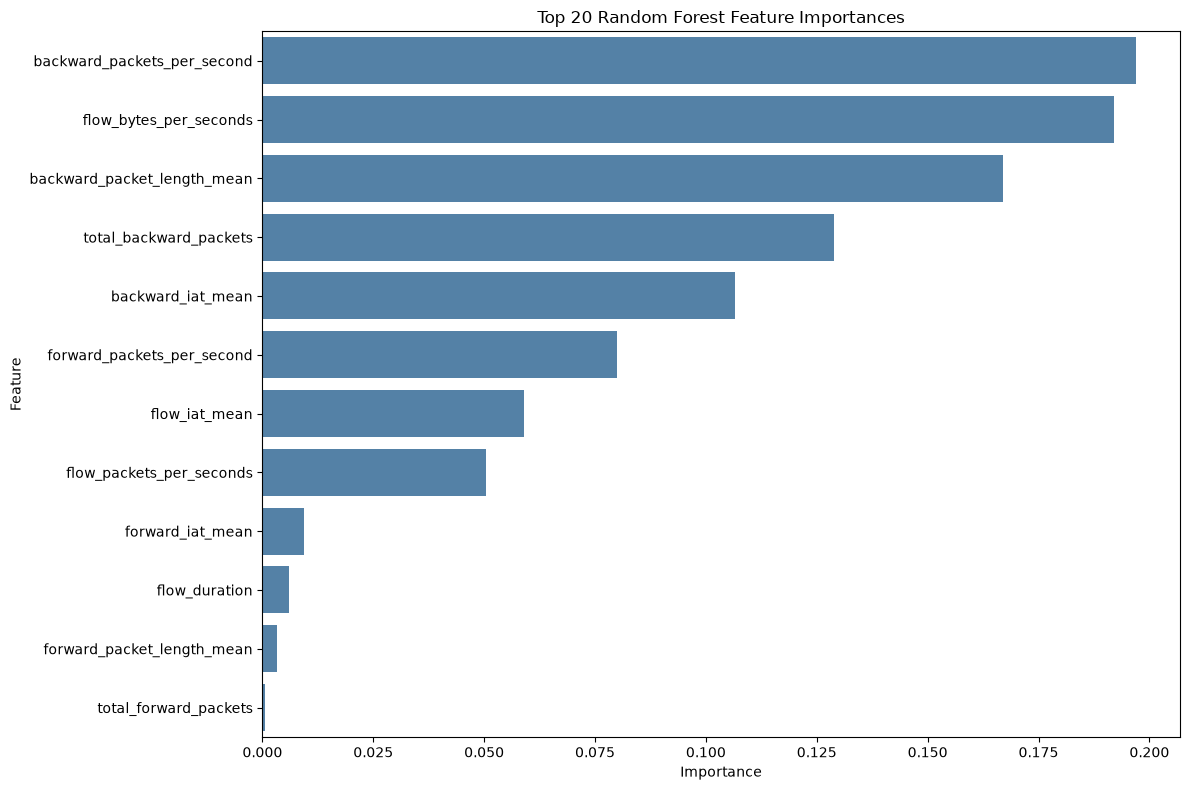

In [36]:
# Get the fitted pipeline
model_pipeline = all_results_df.loc[
    all_results_df['model'] == selected_model, 'model_data'
].iloc[0]

# Extract transformed feature names from the preprocessor
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get random forest feature importances
importances = model_pipeline.named_steps['model'].feature_importances_

# Build a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Remove the preprocessing prefixes
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('num__', '', regex=False)
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('remainder__', '', regex=False)

# Sort and show top features
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_features, x='Importance', y='Feature', color='steelblue')
plt.title(f'Top {top_n} Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()